In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pycontrails import Fleet

In [2]:
dff = pd.read_parquet("../data/filed_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000].parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/optimised_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000].parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

Fleet contains 4112 flights
Fleet contains 4112 flights


In [3]:
from cane.utils import mask_by_marker

mask_by_marker(fleetf, ["nox", "NOx", "O3", "CH4", "H2O"])
mask_by_marker(fleeto, ["nox", "NOx", "O3", "CH4", "H2O"])

dff = fleetf.dataframe
dfo = fleeto.dataframe

Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O


In [4]:
from cane.utils import mask_by_validity_range

bounds = [150, 350]
mask_by_validity_range(fleetf, ["nox", "NOx", "O3", "CH4", "H2O"], bounds)
mask_by_validity_range(fleeto, ["nox", "NOx", "O3", "CH4", "H2O"], bounds)

dff = fleetf.dataframe
dfo = fleeto.dataframe

Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for H2O
Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for H2O


In [5]:
dff["CO2_CoCiP"] = dff["CO2"] + dff["CoCiP"]
dfo["CO2_CoCiP"] = dfo["CO2"] + dfo["CoCiP"]

dff["NOx_H2O"] = dff["NOx"] + dff["H2O"]
dfo["NOx_H2O"] = dfo["NOx"] + dfo["H2O"]

dff["Total"] = dff["CO2"] + dff["CoCiP"] + dff["NOx"] + dff["H2O"]
dfo["Total"] = dfo["CO2"] + dfo["CoCiP"] + dfo["NOx"] + dfo["H2O"]

In [6]:
from cane.utils import df_diff

# create aggregates (total)
org_sum = (
    dff[["flight_id", "fuel_burn", "nox", "co2", "CO2", "NOx", "H2O", "CoCiP", "CO2_CoCiP", "NOx_H2O",
         "Total"]]
    .groupby(["flight_id"]).sum().reset_index()
)
opt_sum = (
    dfo[["flight_id", "fuel_burn", "nox", "co2", "CO2", "NOx", "H2O", "CoCiP", "CO2_CoCiP", "NOx_H2O",
         "Total"]]
    .groupby(["flight_id"]).sum().reset_index()
)
my_diff = df_diff(org_sum, opt_sum, on=["flight_id"], keep_originals=True)
my_diff = pd.merge(
    my_diff,
    dff.groupby("flight_id").day.first(),
    on="flight_id",
)

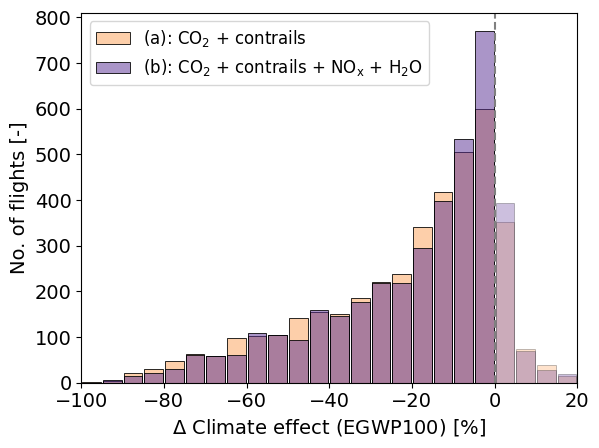

In [7]:
fig, ax = plt.subplots()

ax1 = sns.histplot(my_diff["CO2_CoCiP_reldiff"] * 100, label="(a): CO$_2$ + contrails",
                   binwidth=5, binrange=(-150, 100),
                   alpha=.5, color=sns.color_palette("Oranges")[2], shrink=0.9)  #, edgecolor="white", linewidth=0.5)
ax2 = sns.histplot(my_diff["Total_reldiff"] * 100,
                   label=r"(b): CO$_2$ + contrails + NO$\rm_x$ + H$_2$O",
                   binwidth=5, binrange=(-150, 100),
                   alpha=.5, color=sns.color_palette("Purples")[5], shrink=0.9)  #edgecolor="white", linewidth=0.5)

for patch in ax1.patches:
    if patch.get_x() >= 0:
        patch.set_alpha(0.3)  # lighter alpha
        # patch.set_hatch("//")  # or hatches, or both

ax.set_xlim([-100, 20])
plt.xlabel("$\Delta$ Climate effect (EGWP100) [%]", fontsize=14)
plt.ylabel("No. of flights [-]", fontsize=14)
plt.tick_params(labelsize=14)
# plt.title("Climate optimized flights only")
# plt.grid(axis=None)
plt.legend(fontsize=12, loc="upper left")
plt.axvline(0, color="gray", linestyle="--")

# # left text
# left_share = my_diff.query("CO2_CoCiP_reldiff < 0").shape[0] / my_diff.flight_id.nunique() * 100
# fig.text(
#     0.15, 0.7, f"{left_share:.1f}%",
#     ha="left", va="top",
#     fontsize=12,
#     bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey")
# )
#
# # right text
# right_share = my_diff.query("CO2_CoCiP_reldiff < 0").shape[0] / my_diff.flight_id.nunique() * 100
# fig.text(
#     0.15, 0.7, f"{right_share:.1f}%",
#     ha="left", va="top",
#     fontsize=12,
#     bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey")
# )

plt.savefig("./figures/fig07.png", dpi=300, bbox_inches="tight")